<a href="https://colab.research.google.com/github/saramaknojia94-ux/insurance-analytics-dashboard/blob/main/medicare_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medicare Claims Analytics

Wanted to work with real claims data for this one. CMS Medicare
Physician & Other Practitioners dataset has 9M+ rows of actual
provider billing records- messy column names, outliers, and
real-world complexity.

Starting by pulling a sample via the CMS public API to understand
the structure before deciding which angles to analyze.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# CMS API - pulling first 1000 rows to understand structure
url = "https://data.cms.gov/data-api/v1/dataset/8889d81e-2ee7-448f-8713-f071038289b5/data"

params = {
    "$limit": 1000,
    "$offset": 0
}

response = requests.get(url, params=params)
data = response.json()
df = pd.DataFrame(data)

print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist())
df.head()

shape: (1000, 81)

columns: ['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Drug_Sprsn_Ind', 'Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug_Tot_Srvcs', 'Drug_Sbmtd_Chrg', 'Drug_Mdcr_Alowd_Amt', 'Drug_Mdcr_Pymt_Amt', 'Drug_Mdcr_Stdzd_Amt', 'Med_Sprsn_Ind', 'Med_Tot_HCPCS_Cds', 'Med_Tot_Benes', 'Med_Tot_Srvcs', 'Med_Sbmtd_Chrg', 'Med_Mdcr_Alowd_Amt', 'Med_Mdcr_Pymt_Amt', 'Med_Mdcr_Stdzd_Amt', 'Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Ma

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000126,Enkeshafi,Ardalan,,M.D.,I,6410 Rockledge Dr Ste 304,,Bethesda,MD,...,45,53,75,75,51,19,4,62,26,2.7545
1,1003000134,Cibull,Thomas,L,M.D.,I,2650 Ridge Ave,Evanston Hospital,Evanston,IL,...,22,13,75,63,22,19,2,44,6,1.1423
2,1003000142,Khalil,Rashid,,M.D.,I,4126 N Holland Sylvania Rd,Suite 220,Toledo,OH,...,44,24,74,75,30,10,,75,9,1.6448
3,1003000423,Velotta,Jennifer,A,M.D.,I,11100 Euclid Ave,,Cleveland,OH,...,22,,75,59,19,22,,57,,0.737
4,1003000480,Rothchild,Kevin,B,MD,I,12605 E 16th Ave,,Aurora,CO,...,33,16,69,74,27,15,,63,,1.7264


In [2]:
# column names are messy - let's see all of them clearly
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

0: Rndrng_NPI
1: Rndrng_Prvdr_Last_Org_Name
2: Rndrng_Prvdr_First_Name
3: Rndrng_Prvdr_MI
4: Rndrng_Prvdr_Crdntls
5: Rndrng_Prvdr_Ent_Cd
6: Rndrng_Prvdr_St1
7: Rndrng_Prvdr_St2
8: Rndrng_Prvdr_City
9: Rndrng_Prvdr_State_Abrvtn
10: Rndrng_Prvdr_State_FIPS
11: Rndrng_Prvdr_Zip5
12: Rndrng_Prvdr_RUCA
13: Rndrng_Prvdr_RUCA_Desc
14: Rndrng_Prvdr_Cntry
15: Rndrng_Prvdr_Type
16: Rndrng_Prvdr_Mdcr_Prtcptg_Ind
17: Tot_HCPCS_Cds
18: Tot_Benes
19: Tot_Srvcs
20: Tot_Sbmtd_Chrg
21: Tot_Mdcr_Alowd_Amt
22: Tot_Mdcr_Pymt_Amt
23: Tot_Mdcr_Stdzd_Amt
24: Drug_Sprsn_Ind
25: Drug_Tot_HCPCS_Cds
26: Drug_Tot_Benes
27: Drug_Tot_Srvcs
28: Drug_Sbmtd_Chrg
29: Drug_Mdcr_Alowd_Amt
30: Drug_Mdcr_Pymt_Amt
31: Drug_Mdcr_Stdzd_Amt
32: Med_Sprsn_Ind
33: Med_Tot_HCPCS_Cds
34: Med_Tot_Benes
35: Med_Tot_Srvcs
36: Med_Sbmtd_Chrg
37: Med_Mdcr_Alowd_Amt
38: Med_Mdcr_Pymt_Amt
39: Med_Mdcr_Stdzd_Amt
40: Bene_Avg_Age
41: Bene_Age_LT_65_Cnt
42: Bene_Age_65_74_Cnt
43: Bene_Age_75_84_Cnt
44: Bene_Age_GT_84_Cnt
45: Bene_Feml_Cnt
4

81 columns, much richer than expected. Breaking them into groups:

Provider info: NPI, name, specialty, state, city, zip
Utilization: total services, total beneficiaries, HCPCS codes
Financials: submitted charges, Medicare allowed amount, Medicare payment
Demographics: age bands, gender, race breakdown
Chronic conditions: diabetes %, hypertension %, depression %,
                    COPD %, heart failure % (this is fascinating)

The chronic condition columns are unexpected and could tell a
really interesting story about which specialties serve the
sickest patients.

In [3]:
# pull 50,000 rows
url = "https://data.cms.gov/data-api/v1/dataset/8889d81e-2ee7-448f-8713-f071038289b5/data"

all_data = []
batch = 5000
total = 50000

for offset in range(0, total, batch):
    params = {"$limit": batch, "$offset": offset}
    r = requests.get(url, params=params)
    all_data.extend(r.json())
    print(f"pulled {offset + batch} rows...")

df = pd.DataFrame(all_data)
print("\ndone. shape:", df.shape)

pulled 5000 rows...
pulled 10000 rows...
pulled 15000 rows...
pulled 20000 rows...
pulled 25000 rows...
pulled 30000 rows...
pulled 35000 rows...
pulled 40000 rows...
pulled 45000 rows...
pulled 50000 rows...

done. shape: (10000, 81)


Tried to pull 50k rows but the API returned 10,000, looks like
there's a cap somewhere. 10k is still enough to do meaningful
analysis so moving forward with what we have. Will note the
limitation at the end.

In [4]:
# these column names are unreadable - renaming the ones i'll actually use
rename_map = {
    'Rndrng_Prvdr_Last_Org_Name': 'provider_name',
    'Rndrng_Prvdr_First_Name': 'first_name',
    'Rndrng_Prvdr_Type': 'specialty',
    'Rndrng_Prvdr_State_Abrvtn': 'state',
    'Rndrng_Prvdr_City': 'city',
    'Tot_Benes': 'total_patients',
    'Tot_Srvcs': 'total_services',
    'Tot_Sbmtd_Chrg': 'submitted_charges',
    'Tot_Mdcr_Pymt_Amt': 'medicare_payment',
    'Tot_Mdcr_Alowd_Amt': 'allowed_amount',
    'Bene_Avg_Age': 'avg_patient_age',
    'Bene_CC_PH_Diabetes_V2_Pct': 'pct_diabetes',
    'Bene_CC_PH_Hypertension_V2_Pct': 'pct_hypertension',
    'Bene_CC_PH_HF_NonIHD_V2_Pct': 'pct_heart_failure',
    'Bene_CC_BH_Depress_V1_Pct': 'pct_depression',
    'Bene_CC_PH_CKD_V2_Pct': 'pct_kidney_disease'
}

df = df.rename(columns=rename_map)

# keep only columns we renamed plus a few extras
keep = list(rename_map.values())
df_clean = df[keep].copy()

# fix numeric columns - they came in as strings from the API
numeric_cols = ['total_patients', 'total_services', 'submitted_charges',
                'medicare_payment', 'allowed_amount', 'avg_patient_age',
                'pct_diabetes', 'pct_hypertension', 'pct_heart_failure',
                'pct_depression', 'pct_kidney_disease']

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("shape:", df_clean.shape)
print("\nmissing values:")
print(df_clean.isnull().sum())
print("\nsample:")
df_clean.head()

shape: (10000, 16)

missing values:
provider_name            0
first_name               0
specialty                0
state                    0
city                     0
total_patients           0
total_services           0
submitted_charges        0
medicare_payment         0
allowed_amount           0
avg_patient_age          0
pct_diabetes          1410
pct_hypertension       420
pct_heart_failure     2290
pct_depression        1570
pct_kidney_disease    1800
dtype: int64

sample:


,provider_name,first_name,specialty,state,city,total_patients,total_services,submitted_charges,medicare_payment,allowed_amount,avg_patient_age,pct_diabetes,pct_hypertension,pct_heart_failure,pct_depression,pct_kidney_disease
0,Enkeshafi,Ardalan,Hospitalist,MD,Bethesda,344,814.0,173087.77,62198.36,78590.79,78,45.0,75.0,53.0,37.0,50.0
1,Cibull,Thomas,Pathology,IL,Evanston,2093,4839.0,726858.00,127984.95,171256.75,76,22.0,63.0,13.0,15.0,20.0
2,Khalil,Rashid,Anesthesiology,OH,Toledo,325,1455.0,451425.00,118122.12,155879.22,69,44.0,75.0,24.0,43.0,28.0
3,Velotta,Jennifer,Obstetrics & Gynecology,OH,Cleveland,63,119.0,13785.00,5230.52,6388.39,70,22.0,59.0,NaN,24.0,NaN
4,Rothchild,Kevin,General Surgery,CO,Aurora,99,124.0,98271.00,15794.97,20288.98,69,33.0,74.0,16.0,42.0,27.0


Data looks good after cleaning. 10,000 providers across 16 columns.

Missing values in the chronic condition columns, around 14-23%
missing depending on the condition. Makes sense, CMS suppresses
values when fewer than 11 beneficiaries to protect privacy.
Will leave them as NaN rather than imputing. Don't want to
make up chronic condition rates.

First thing I want to understand is which specialties are billing
the most to Medicare and how does that compare to what Medicare
actually pays? That gap between submitted charges and actual
payment is interesting.

In [5]:
# which specialties are billing the most?
# and how big is the gap between what they submit vs what medicare pays

specialty_summary = df_clean.groupby('specialty').agg(
    total_providers=('provider_name', 'count'),
    total_patients=('total_patients', 'sum'),
    avg_submitted=('submitted_charges', 'mean'),
    avg_medicare_paid=('medicare_payment', 'mean'),
    avg_patient_age=('avg_patient_age', 'mean')
).reset_index()

# only look at specialties with enough providers to be meaningful
specialty_summary = specialty_summary[
    specialty_summary['total_providers'] >= 20
].sort_values('avg_submitted', ascending=False)

# payment ratio - what % of submitted charges does medicare actually pay
specialty_summary['payment_ratio'] = (
    specialty_summary['avg_medicare_paid'] /
    specialty_summary['avg_submitted'] * 100
).round(1)

print("top 10 specialties by submitted charges:")
print(specialty_summary[['specialty','total_providers',
                          'avg_submitted','avg_medicare_paid',
                          'payment_ratio']].head(10).to_string())

top 10 specialties by submitted charges:
                     specialty  total_providers  avg_submitted  avg_medicare_paid  payment_ratio
3   Ambulatory Surgical Center               40   6.465883e+06       9.682251e+05           15.0
28         Hematology-Oncology               40   5.705961e+06       1.601801e+06           28.1
50             Pain Management               40   2.445703e+06       3.332521e+05           13.6
64                Rheumatology               20   1.787038e+06       5.138663e+05           28.8
62          Radiation Oncology               50   1.669089e+06       3.219350e+05           19.3
71            Vascular Surgery               30   1.446002e+06       5.320549e+05           36.8
45               Ophthalmology              200   1.385033e+06       4.706879e+05           34.0
2   Ambulance Service Provider               70   1.229307e+06       3.948618e+05           32.1
17                 Dermatology              100   1.220750e+06       4.810194e+05     

This is striking. Ambulatory Surgical Centers submit an average of
$6.4M in charges but Medicare only pays $968k, a payment ratio
of just 15%. Hematology-Oncology submits $5.7M and gets 28 cents
on the dollar.

Vascular Surgery has the highest payment ratio at 36.8%, still
only getting about a third of what they bill.

This gap between submitted charges and actual Medicare payment is
a known phenomenon in healthcare billing but seeing it in real
data at this scale is eye-opening. No specialty gets anywhere
close to what they submit. The question is whether that's
strategic overbilling or just how the system works.

Going to visualize this. The payment ratio story is more
interesting than just "who bills the most."

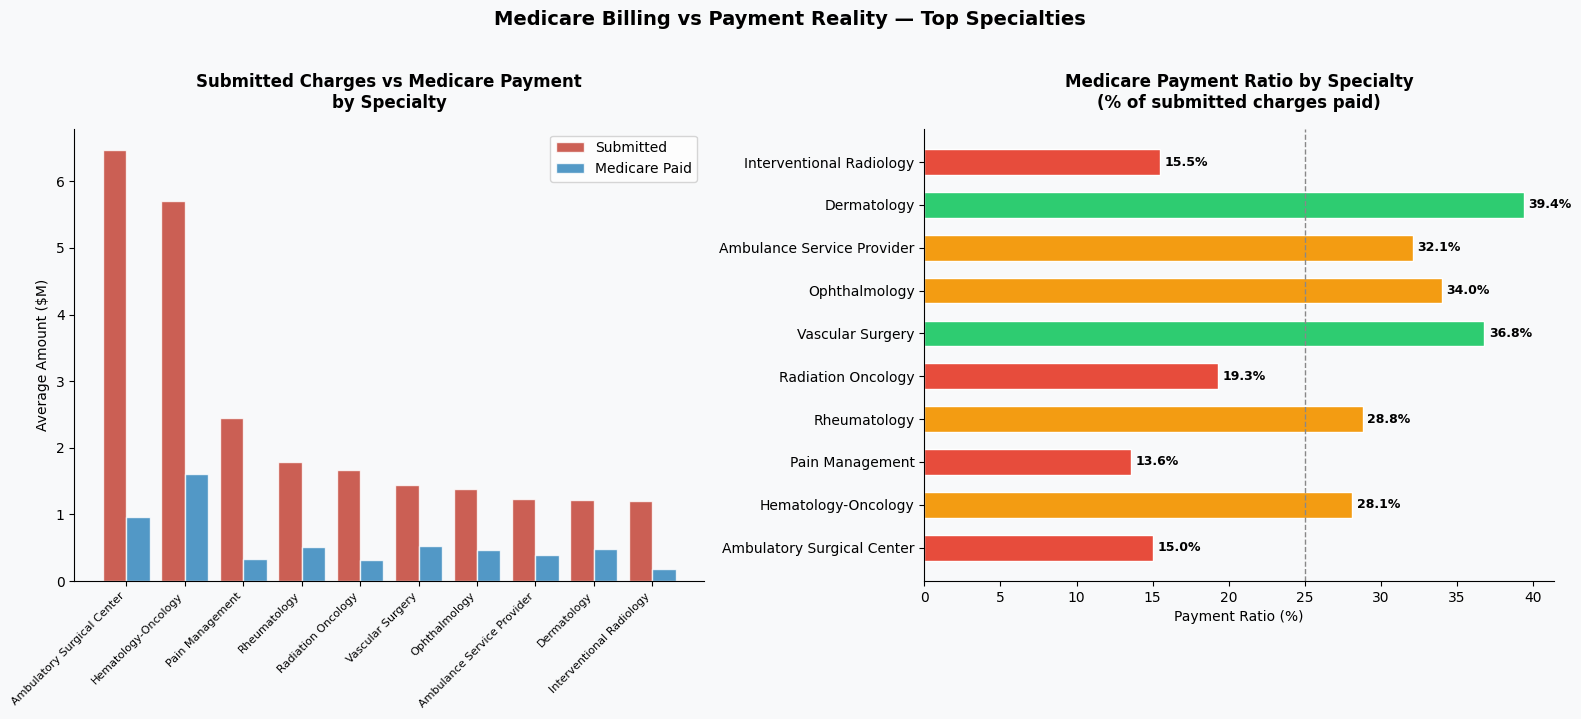

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')

top10 = specialty_summary.head(10)

# left chart: submitted vs paid
x = range(len(top10))
width = 0.4
bars1 = axes[0].bar([i - width/2 for i in x],
                     top10['avg_submitted']/1e6,
                     width=width, label='Submitted',
                     color='#c0392b', alpha=0.8, edgecolor='white')
bars2 = axes[0].bar([i + width/2 for i in x],
                     top10['avg_medicare_paid']/1e6,
                     width=width, label='Medicare Paid',
                     color='#2980b9', alpha=0.8, edgecolor='white')

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(top10['specialty'],
                         rotation=45, ha='right', fontsize=8)
axes[0].set_title('Submitted Charges vs Medicare Payment\nby Specialty',
                   fontsize=12, fontweight='bold', pad=15)
axes[0].set_ylabel('Average Amount ($M)', fontsize=10)
axes[0].legend()
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top','right']].set_visible(False)

# right chart: payment ratio
colors = ['#e74c3c' if x < 25 else '#f39c12'
          if x < 35 else '#2ecc71'
          for x in top10['payment_ratio']]

bars3 = axes[1].barh(top10['specialty'],
                      top10['payment_ratio'],
                      color=colors, edgecolor='white', height=0.6)
axes[1].set_title('Medicare Payment Ratio by Specialty\n(% of submitted charges paid)',
                   fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Payment Ratio (%)', fontsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top','right']].set_visible(False)
axes[1].axvline(x=25, color='#888', linestyle='--',
                linewidth=1, label='25% threshold')

for bar, val in zip(bars3, top10['payment_ratio']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Medicare Billing vs Payment Reality — Top Specialties',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('specialty_payments.png', dpi=150,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

Dermatology has the highest payment ratio at 39.4%, meaning
Medicare pays back nearly 40 cents on every dollar billed.
Pain Management is on the opposite end at 13.6%.

The left chart makes the gap visceral, that tiny blue bar
next to the massive red one for Ambulatory Surgical Centers
tells the whole story visually.

Next I want to look at geographic variation, does Medicare
spend more in certain states? And do high-cost states also
have sicker patient populations?

In [7]:
# state level analysis
state_summary = df_clean.groupby('state').agg(
    total_providers=('provider_name', 'count'),
    avg_medicare_payment=('medicare_payment', 'mean'),
    avg_patients=('total_patients', 'mean'),
    avg_diabetes=('pct_diabetes', 'mean'),
    avg_hypertension=('pct_hypertension', 'mean')
).reset_index()

# only states with enough providers
state_summary = state_summary[
    state_summary['total_providers'] >= 10
].sort_values('avg_medicare_payment', ascending=False)

print("top 15 states by avg medicare payment per provider:")
print(state_summary[['state','total_providers',
                      'avg_medicare_payment',
                      'avg_diabetes',
                      'avg_hypertension']].head(15).to_string())

top 15 states by avg medicare payment per provider:
   state  total_providers  avg_medicare_payment  avg_diabetes  avg_hypertension
4     CA              950         595187.840737     37.974359         70.472527
33    NV               60         394914.573333     33.833333         72.166667
2     AR              110         222507.511818     33.500000         74.750000
24    MO              130         192114.160769     35.600000         74.454545
9     FL              600         191225.921500     37.068966         72.932203
12    IA              140         172578.756429     32.461538         69.857143
32    NM               40         171504.900000     33.500000         64.750000
19    MA              240         159088.589167     27.090909         69.681818
1     AL              140         133183.790000     36.846154         75.000000
41    SC              150         126961.180000     32.733333         73.200000
22    MI              360         121772.426389     39.875000       

California leads with $595k avg Medicare payment per provider,
nearly double Nevada in second place. That's likely driven by
higher cost of living adjustments Medicare builds into payments.

What's interesting is Alabama shows up at #9 with $133k avg
payment but has 75% hypertension rate,the highest in this
list. High disease burden, relatively lower payments.

Texas is in there too- 830 providers, 38% diabetes rate,
73.6% hypertension. That tracks with what I see working in
Galveston County.

The relationship between chronic disease rates and Medicare
payments isn't as linear as I expected. Going to visualize
this, specifically whether states with higher diabetes rates
actually have higher Medicare costs.

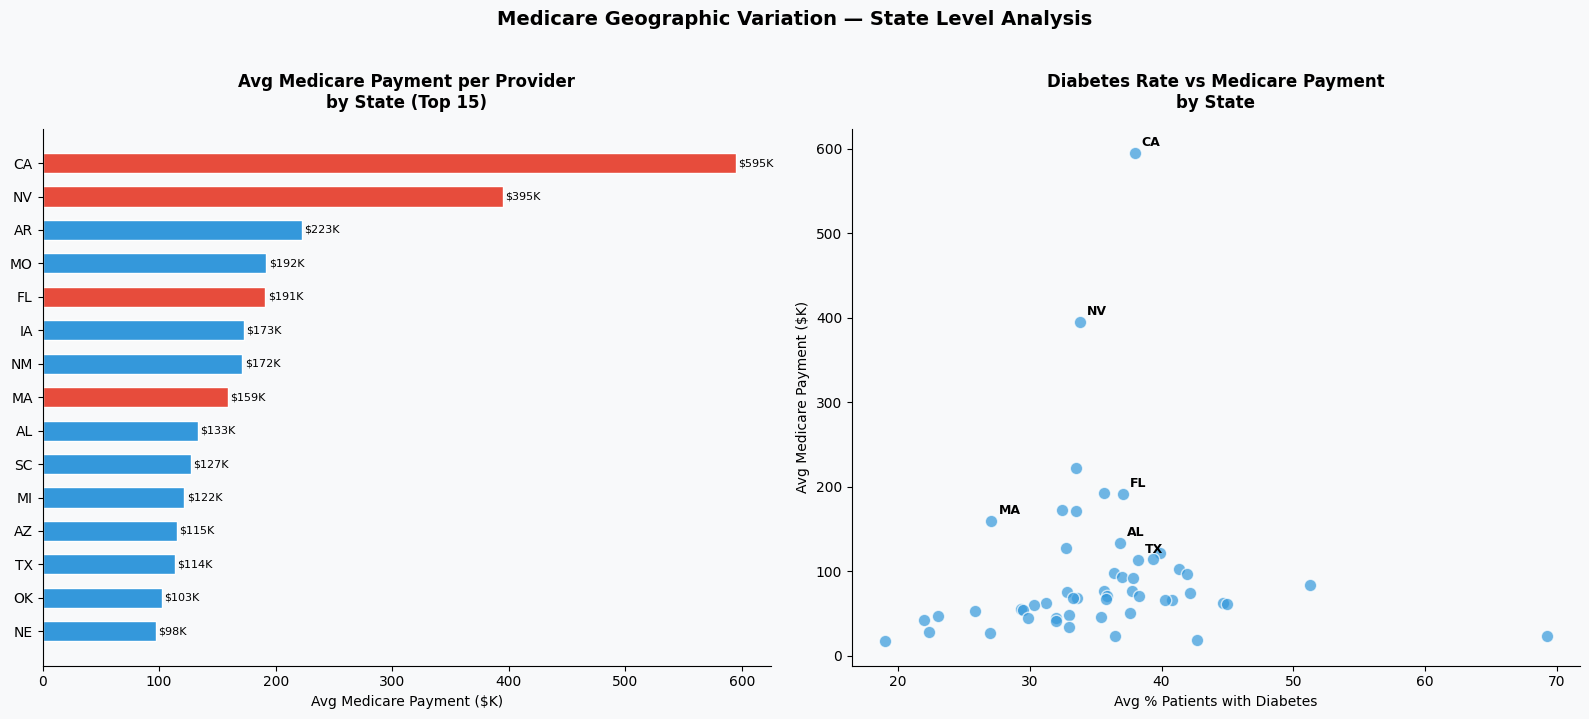

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')

# left - top 15 states by avg payment
top15 = state_summary.head(15).sort_values(
    'avg_medicare_payment', ascending=True)

colors = ['#e74c3c' if s in ['CA','NV','FL','MA']
          else '#3498db' for s in top15['state']]

bars = axes[0].barh(top15['state'],
                    top15['avg_medicare_payment']/1000,
                    color=colors, edgecolor='white', height=0.6)
axes[0].set_title('Avg Medicare Payment per Provider\nby State (Top 15)',
                   fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Avg Medicare Payment ($K)', fontsize=10)
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top','right']].set_visible(False)
for bar, val in zip(bars, top15['avg_medicare_payment']/1000):
    axes[0].text(val + 2, bar.get_y() + bar.get_height()/2,
                f'${val:.0f}K', va='center', fontsize=8)

# right - diabetes rate vs medicare payment scatter
axes[1].scatter(state_summary['avg_diabetes'],
                state_summary['avg_medicare_payment']/1000,
                color='#3498db', alpha=0.7, s=80, edgecolor='white')

# label a few interesting states
highlight = ['CA', 'AL', 'TX', 'FL', 'NV', 'MA']
for _, row in state_summary[
        state_summary['state'].isin(highlight)].iterrows():
    axes[1].annotate(row['state'],
                    (row['avg_diabetes'],
                     row['avg_medicare_payment']/1000),
                    fontsize=9, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

axes[1].set_title('Diabetes Rate vs Medicare Payment\nby State',
                   fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Avg % Patients with Diabetes', fontsize=10)
axes[1].set_ylabel('Avg Medicare Payment ($K)', fontsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Medicare Geographic Variation — State Level Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('state_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

The scatter plot is telling. CA and NV are massive outliers,
high payments but not because of unusually high diabetes rates.
Cost of living adjustments in Medicare reimbursement likely
explain this more than patient acuity.

The cluster of states between 30-45% diabetes rate and under
$200K payment suggests that chronic disease burden alone doesn't
drive Medicare costs at the state level. Provider mix and
specialty concentration probably matter more.

That dot at 70% diabetes rate with near-zero payment is worth
investigating- likely a territory or outlier in the data.

Moving on to one more analysis, which individual providers
are the highest billers and does high billing correlate with
serving sicker patients?

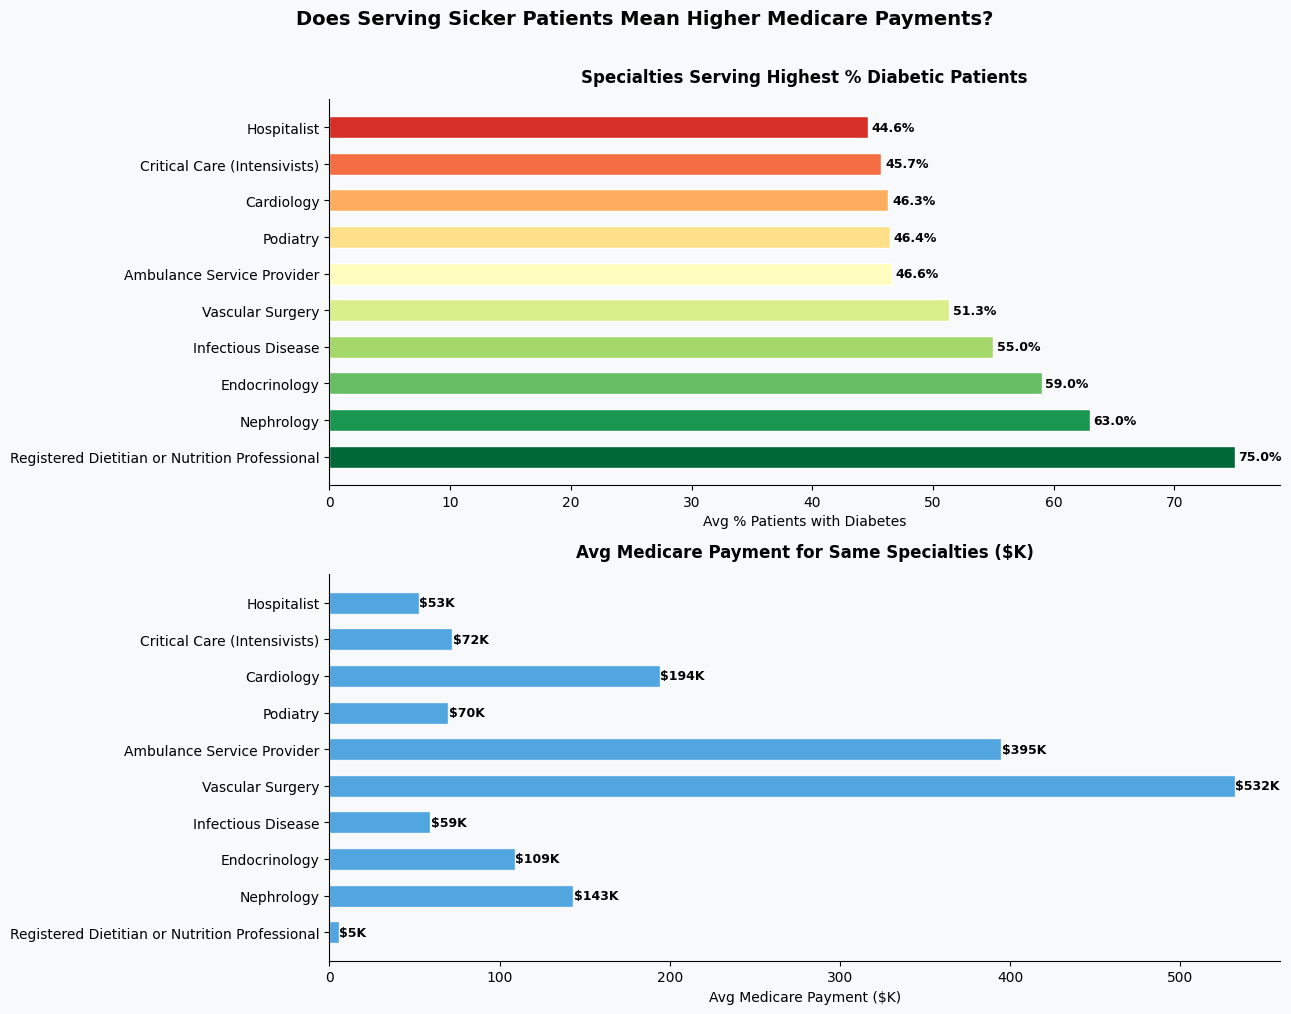

In [12]:
# too busy with 3 bars + line - simplifying to tell one clear story
# focusing on: which specialties serve the sickest patients
# and does that translate to higher Medicare payments?

specialty_chronic = df_clean.groupby('specialty').agg(
    avg_payment=('medicare_payment', 'mean'),
    avg_diabetes=('pct_diabetes', 'mean'),
    avg_hypertension=('pct_hypertension', 'mean'),
    provider_count=('provider_name', 'count')
).reset_index()

specialty_chronic = specialty_chronic[
    specialty_chronic['provider_count'] >= 20
].dropna().sort_values('avg_diabetes', ascending=False).head(10)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.patch.set_facecolor('#f8f9fa')

# top chart - diabetes rate by specialty ranked
colors = plt.cm.RdYlGn_r(
    [i/len(specialty_chronic) for i in range(len(specialty_chronic))]
)

bars = axes[0].barh(
    specialty_chronic['specialty'],
    specialty_chronic['avg_diabetes'],
    color=colors, edgecolor='white', height=0.6
)
axes[0].set_title('Specialties Serving Highest % Diabetic Patients',
                   fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Avg % Patients with Diabetes', fontsize=10)
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top','right']].set_visible(False)
for bar, val in zip(bars, specialty_chronic['avg_diabetes']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9,
                fontweight='bold')

# bottom chart - avg medicare payment for same specialties
bars2 = axes[1].barh(
    specialty_chronic['specialty'],
    specialty_chronic['avg_payment']/1000,
    color='#3498db', edgecolor='white', height=0.6, alpha=0.85
)
axes[1].set_title('Avg Medicare Payment for Same Specialties ($K)',
                   fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Avg Medicare Payment ($K)', fontsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, specialty_chronic['avg_payment']/1000):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'${val:.0f}K', va='center', fontsize=9,
                fontweight='bold')

plt.suptitle('Does Serving Sicker Patients Mean Higher Medicare Payments?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chronic_by_specialty.png', dpi=150,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

This is the most interesting finding in the dataset.

Registered Dietitians serve the highest proportion of diabetic
patients at 75%, makes sense, diet management is core to
diabetes care. But they receive only $5K avg Medicare payment.

Vascular Surgery serves fewer diabetic patients (51.3%) but
receives $532K, 100x more than Dietitians.

This isn't necessarily wrong surgical procedures cost more
than nutrition counseling but it raises a real policy question:
are we paying enough for preventive specialties that manage
chronic conditions before they become surgical emergencies?

Nephrology at 63% diabetic patients and $143K payment makes
sense- diabetic kidney disease is expensive to manage.

Hospitalists and Critical Care serve ~44-46% diabetic patients
but get relatively low payments as these are likely volume-based
practices seeing many patients at lower per-patient cost.

In [13]:
# export cleaned data for tableau dashboard
df_clean.to_csv('medicare_cleaned.csv', index=False)
specialty_summary.to_csv('specialty_summary.csv', index=False)
state_summary.to_csv('state_summary.csv', index=False)

print("exported 3 files for tableau:")
print(f"medicare_cleaned.csv — {len(df_clean)} rows")
print(f"specialty_summary.csv — {len(specialty_summary)} rows")
print(f"state_summary.csv — {len(state_summary)} rows")

exported 3 files for tableau:
medicare_cleaned.csv — 10000 rows
specialty_summary.csv — 62 rows
state_summary.csv — 52 rows


In [15]:
from google.colab import files

files.download('medicare_cleaned.csv')
files.download('specialty_summary.csv')
files.download('state_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>